In [4]:

import pandas as pd
import matplotlib.pyplot as plt

# URL to the raw NASA Turbofan dataset (Engine 1 Train data)
url  = "https://raw.githubusercontent.com/edwardzjl/CMAPSSData/master/train_FD001.txt"

# Define the names of the sensor columns
columns = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 
           'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 
           'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 
           'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 
           'sensor_20', 'sensor_21']

# Read the data into a Pandas DataFrame
df = pd.read_csv(url, sep=r'\s+', header=None, names=columns)

# Display the first 5 rows of the data
df.head()


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
# Calculate and display the summary statistics for all sensors
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


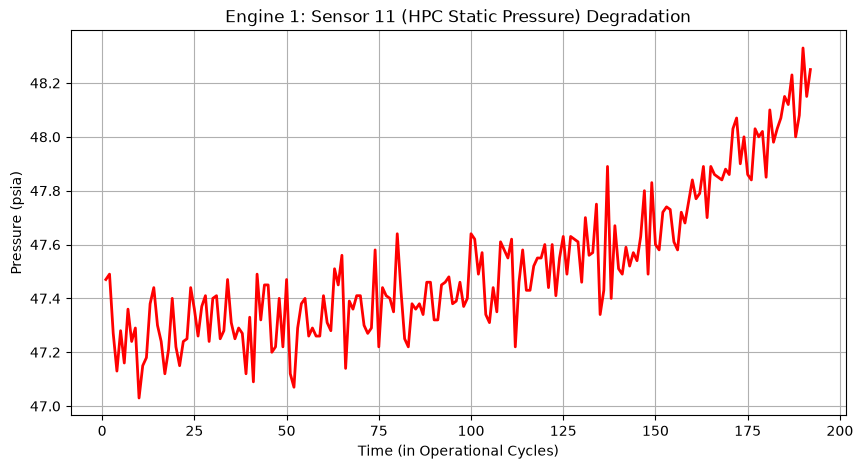

In [6]:
# Isolate the data for only Engine #1
engine_1 = df[df['unit_number'] == 1]

# Create a canvas for our graph (width: 10, height: 5)
plt.figure(figsize=(10, 5))

# Draw the line graph: X-axis is time, Y-axis is Sensor 11
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_11'], color='red', linewidth=2)

# Add titles and labels so the graph is easy to read
plt.title('Engine 1: Sensor 11 (HPC Static Pressure) Degradation')
plt.xlabel('Time (in Operational Cycles)')
plt.ylabel('Pressure (psia)')
plt.grid(True)

# Display the graph
plt.show()

In [7]:
# 1. Find the absolute maximum number of cycles for each specific engine
max_cycles = df.groupby('unit_number')['time_in_cycles'].transform('max')

# 2. Calculate the Remaining Useful Life (RUL) 
# Formula: (Maximum Cycles) - (Current Cycle)
df['RUL'] = max_cycles - df['time_in_cycles']

# 3. Display the first 10 rows of Engine 1 to verify our math
df[['unit_number', 'time_in_cycles', 'RUL']].head(10)

,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [8]:
# Find columns where the standard deviation is exactly 0 (the values never change)
useless_columns = df.columns[df.std() == 0]

print("Sensors with constant values (Dead Gauges):")
print(useless_columns.tolist())

# Drop these useless columns from our dataframe
df = df.drop(columns=useless_columns)

print(f"\nWe deleted {len(useless_columns)} columns.")
print(f"New dataset size: {df.shape[1]} columns remaining.")

Sensors with constant values (Dead Gauges):
['op_setting_3', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']

We deleted 5 columns.
New dataset size: 22 columns remaining.


In [10]:
# 1. Create X (Features) by dropping the ID columns and the target column
X = df.drop(columns=['unit_number', 'time_in_cycles', 'RUL'])

# 2. Create y (Target) by selecting only the RUL column
y = df['RUL']

# 3. Print the shapes (dimensions) of our new data arrays
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (20631, 19)
Target (y) shape: (20631,)


In [12]:
# Import the splitting tool from the scikit-learn library
from sklearn.model_selection import train_test_split

# Split the data: 80% for training (learning), 20% for testing (evaluation)
# random_state=42 ensures that the random split is exactly the same every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the final sizes of our datasets
print("Training Data (X_train) size:", X_train.shape)
print("Testing Data (X_test) size:", X_test.shape)

Training Data (X_train) size: (16504, 19)
Testing Data (X_test) size: (4127, 19)


In [14]:
# Import the Random Forest Regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the model 
# n_estimators=100 means the AI will build 100 different "decision trees" and average their guesses
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model! (This is where the AI actually learns)
# We give it the sensor readings (X_train) and the correct answers (y_train)
model.fit(X_train, y_train)

print("Model training complete! The AI has learned the degradation signatures.")

Model training complete! The AI has learned the degradation signatures.


In [16]:
# Import evaluation metrics from scikit-learn and numpy for math
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Ask the AI to predict the RUL for the unseen testing data
predictions = model.predict(X_test)

# 2. Calculate the metrics to see how far off the AI is
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

# 3. Print the results
print("--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} cycles")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cycles")

--- Model Evaluation ---
Mean Absolute Error (MAE): 29.63 cycles
Root Mean Squared Error (RMSE): 41.44 cycles


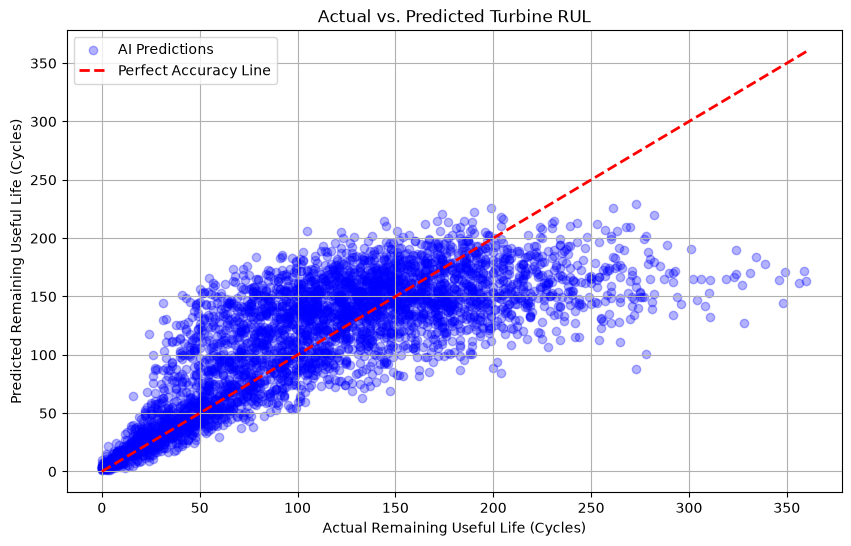

In [18]:
import matplotlib.pyplot as plt

# Set up the chart size
plt.figure(figsize=(10, 6))

# Plot AI predictions against actual answers
plt.scatter(y_test, predictions, alpha=0.3, color='blue', label='AI Predictions')

# Draw a red dashed line representing perfect 100% accuracy
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Accuracy Line')

# Add axis labels and chart title
plt.xlabel('Actual Remaining Useful Life (Cycles)')
plt.ylabel('Predicted Remaining Useful Life (Cycles)')
plt.title('Actual vs. Predicted Turbine RUL')
plt.legend()
plt.grid(True)

# Display the chart
plt.show()

In [20]:
# Set the maximum RUL cap (Piecewise Linear RUL threshold)
MAX_RUL = 125

# Cap the RUL in our dataframe
# If RUL > 125, it becomes 125. Otherwise, it stays the actual value.
df['RUL_capped'] = df['RUL'].clip(upper=MAX_RUL)

# 1. Re-create y (Target) with the new capped RUL
y_capped = df['RUL_capped']

# 2. Re-split the data using the exact same random state
X_train_cap, X_test_cap, y_train_cap, y_test_cap = train_test_split(
    X, y_capped, test_size=0.2, random_state=42
)

# 3. Initialize and train the new "capped" model
model_capped = RandomForestRegressor(n_estimators=100, random_state=42)
print("Training the optimized model... please wait.")
model_capped.fit(X_train_cap, y_train_cap)

# 4. Predict and evaluate
predictions_cap = model_capped.predict(X_test_cap)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae_cap = mean_absolute_error(y_test_cap, predictions_cap)
rmse_cap = np.sqrt(mean_squared_error(y_test_cap, predictions_cap))

print("--- Optimized Model Evaluation ---")
print(f"New Mean Absolute Error (MAE): {mae_cap:.2f} cycles")
print(f"New Root Mean Squared Error (RMSE): {rmse_cap:.2f} cycles")

Training the optimized model... please wait.
--- Optimized Model Evaluation ---
New Mean Absolute Error (MAE): 13.60 cycles
New Root Mean Squared Error (RMSE): 18.79 cycles


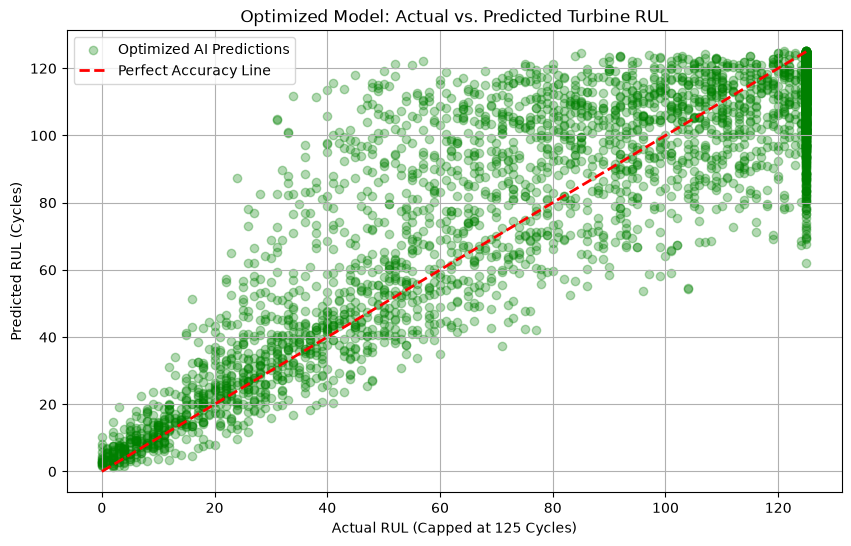

In [22]:
import matplotlib.pyplot as plt

# Set up the chart size
plt.figure(figsize=(10, 6))

# Plot optimized AI predictions against actual capped answers
plt.scatter(y_test_cap, predictions_cap, alpha=0.3, color='green', label='Optimized AI Predictions')

# Draw a red dashed line representing perfect 100% accuracy
plt.plot([y_test_cap.min(), y_test_cap.max()], [y_test_cap.min(), y_test_cap.max()], 'r--', lw=2, label='Perfect Accuracy Line')

# Add axis labels and chart title
plt.xlabel('Actual RUL (Capped at 125 Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.title('Optimized Model: Actual vs. Predicted Turbine RUL')
plt.legend()
plt.grid(True)

# Display the chart
plt.show()

In [23]:
import joblib

# Save the optimized model to a file
model_filename = 'random_forest_rul_model.joblib'
joblib.dump(model_capped, model_filename)

print(f"Success! The trained AI model has been saved as '{model_filename}'")
print("You can now deploy this file to a production environment.")

Success! The trained AI model has been saved as 'random_forest_rul_model.joblib'
You can now deploy this file to a production environment.
